#Course : DSC640

#Name : Tejashri Bhilare

#Week 1 and 2

#Week 1 and 2 exercise : Netflix Viewvership

Step 1: Data Preparation

Download and Load the Data:

First, we will download all 3 netflix datasets.

then Load the required CSV files into pandas DataFrames.

In [6]:

import pandas as pd

# File paths
file_countries = 'C:/Users/Teju/Downloads/all-weeks-countries-netflix.xlsx'
file_global = 'C:/Users/Teju/Downloads/all-weeks-global-netflix.xlsx'
file_popular = 'C:/Users/Teju/Downloads/most-popular-netflix.xlsx'

# Load datasets
countries_data = pd.ExcelFile(file_countries)
global_data = pd.ExcelFile(file_global)
popular_data = pd.ExcelFile(file_popular)

# Check sheet names in the files
print("Sheet names in Countries file:", countries_data.sheet_names)
print("Sheet names in Global file:", global_data.sheet_names)
print("Sheet names in Popular file:", popular_data.sheet_names)

# Load the sheets named "Top 10"
countries_df = countries_data.parse("Top 10")
global_df = global_data.parse("Top 10")
popular_df = popular_data.parse("Top 10")

# Display the first few rows of each dataset
print("\nCountries Data:")
print(countries_df.head())

print("\nGlobal Data:")
print(global_df.head())

print("\nPopular Data:")
print(popular_df.head())



Sheet names in Countries file: ['Top 10']
Sheet names in Global file: ['Top 10']
Sheet names in Popular file: ['Top 10']

Countries Data:
  country_name country_iso2        week category  weekly_rank  \
0    Argentina           AR  2024-04-14    Films            1   
1    Argentina           AR  2024-04-14    Films            2   
2    Argentina           AR  2024-04-14    Films            3   
3    Argentina           AR  2024-04-14    Films            4   
4    Argentina           AR  2024-04-14    Films            5   

                      show_title season_title  cumulative_weeks_in_top_10  
0                  The Tearsmith          NaN                           2  
1                         Stolen          NaN                           1  
2                  Love, Divided          NaN                           1  
3  Woody Woodpecker Goes to Camp          NaN                           1  
4                  Rest In Peace          NaN                           3  

Global Data:
 

**Step 2 : Handling of  Missing Data
We’ll fill missing season titles with "N/A" and drop rows where runtime or weekly_views are critical.**

In [8]:
# Fill missing season titles with "N/A"
countries_df["season_title"].fillna("N/A", inplace=True)
global_df["season_title"].fillna("N/A", inplace=True)
popular_df["season_title"].fillna("N/A", inplace=True)

# Drop rows with missing runtime or weekly_views in global_df
global_df_cleaned = global_df.dropna(subset=["runtime", "weekly_views"])

print(global_df_cleaned.head())


         week         category  weekly_rank                     show_title  \
0  2024-04-14  Films (English)            1              What Jennifer Did   
1  2024-04-14  Films (English)            2  Woody Woodpecker Goes to Camp   
2  2024-04-14  Films (English)            3                          Scoop   
3  2024-04-14  Films (English)            4                          Glass   
4  2024-04-14  Films (English)            5                   Megan Leavey   

  season_title  weekly_hours_viewed  runtime  weekly_views  \
0          N/A             26100000   1.4500    18000000.0   
1          N/A             19600000   1.6667    11800000.0   
2          N/A             14600000   1.7167     8500000.0   
3          N/A             11000000   2.1500     5100000.0   
4          N/A              9700000   1.9333     5000000.0   

   cumulative_weeks_in_top_10  is_staggered_launch episode_launch_details  
0                           1                False                    NaN  
1     

Explore Patterns
We’ll explore the top-performing titles, categories, and weeks.

In [9]:
# Top 10 most popular titles globally
top_global_titles = global_df_cleaned.groupby("show_title")["weekly_hours_viewed"].sum().sort_values(ascending=False).head(10)
print("Top 10 Global Titles by Weekly Hours Viewed:")
print(top_global_titles)

# Top categories by cumulative weeks in the top 10
top_categories = countries_df.groupby("category")["cumulative_weeks_in_top_10"].sum().sort_values(ascending=False)
print("\nTop Categories by Cumulative Weeks in Top 10:")
print(top_categories)

# Weekly trend of global viewing hours
global_weekly_trend = global_df_cleaned.groupby("week")["weekly_hours_viewed"].sum()
print("\nWeekly Trend of Global Viewing Hours:")
print(global_weekly_trend)


Top 10 Global Titles by Weekly Hours Viewed:
show_title
Fool Me Once                 589200000
ONE PIECE                    480300000
King the Land                446900000
Avatar The Last Airbender    442600000
The Gentlemen                407400000
The Witcher                  384400000
Love Is Blind                382400000
Lupin                        352700000
Berlin                       348700000
Griselda                     344100000
Name: weekly_hours_viewed, dtype: int64

Top Categories by Cumulative Weeks in Top 10:
category
TV       653396
Films    291867
Name: cumulative_weeks_in_top_10, dtype: int64

Weekly Trend of Global Viewing Hours:
week
2023-06-18    677700000
2023-06-25    647800000
2023-07-02    607800000
2023-07-09    593100000
2023-07-16    550000000
2023-07-23    535700000
2023-07-30    586300000
2023-08-06    609000000
2023-08-13    542800000
2023-08-20    508000000
2023-08-27    563400000
2023-09-03    625600000
2023-09-10    627000000
2023-09-17    582100000

### Visualizations

We’ll use matplotlib and seaborn to create visuals.

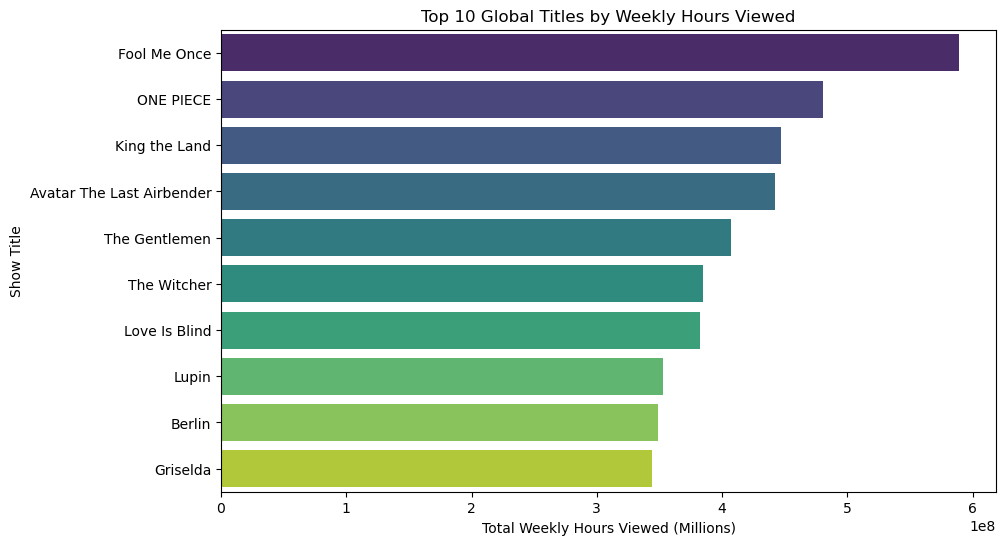

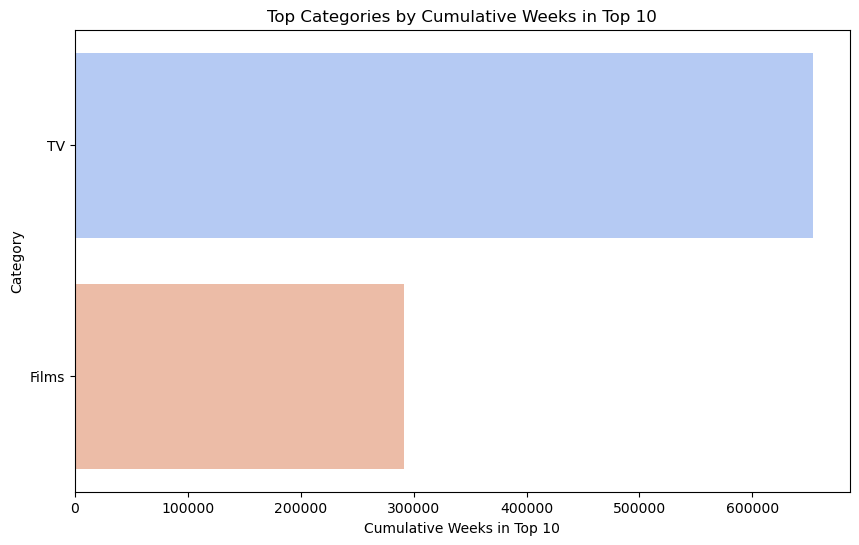

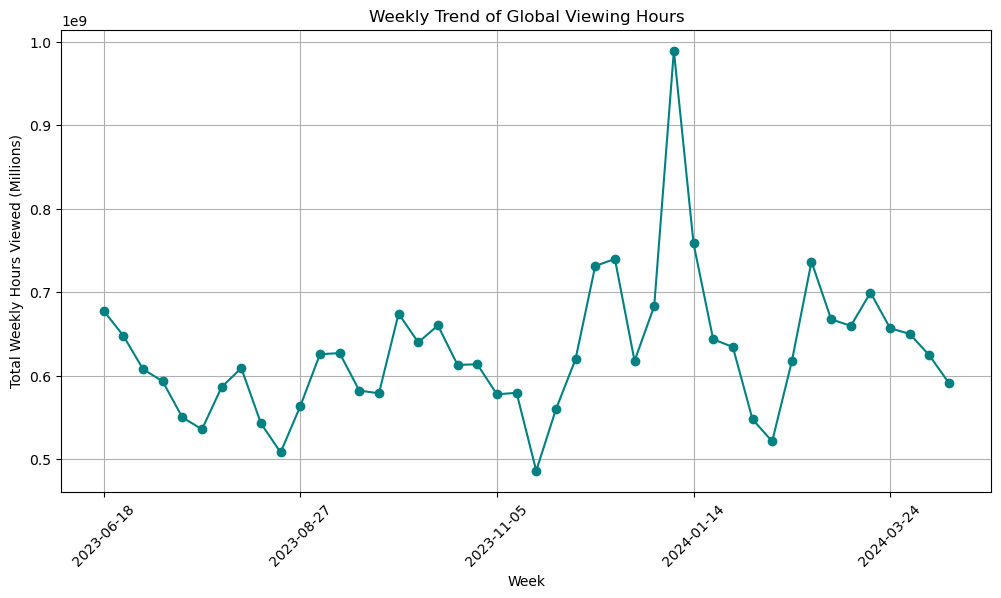

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 Global Titles Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=top_global_titles.values, y=top_global_titles.index, palette="viridis")
plt.title("Top 10 Global Titles by Weekly Hours Viewed")
plt.xlabel("Total Weekly Hours Viewed (Millions)")
plt.ylabel("Show Title")
plt.show()

# Top Categories Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="coolwarm")
plt.title("Top Categories by Cumulative Weeks in Top 10")
plt.xlabel("Cumulative Weeks in Top 10")
plt.ylabel("Category")
plt.show()

# Weekly Trend of Global Viewing Hours Visualization
plt.figure(figsize=(12, 6))
global_weekly_trend.plot(kind='line', marker='o', color='teal')
plt.title("Weekly Trend of Global Viewing Hours")
plt.xlabel("Week")
plt.ylabel("Total Weekly Hours Viewed (Millions)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


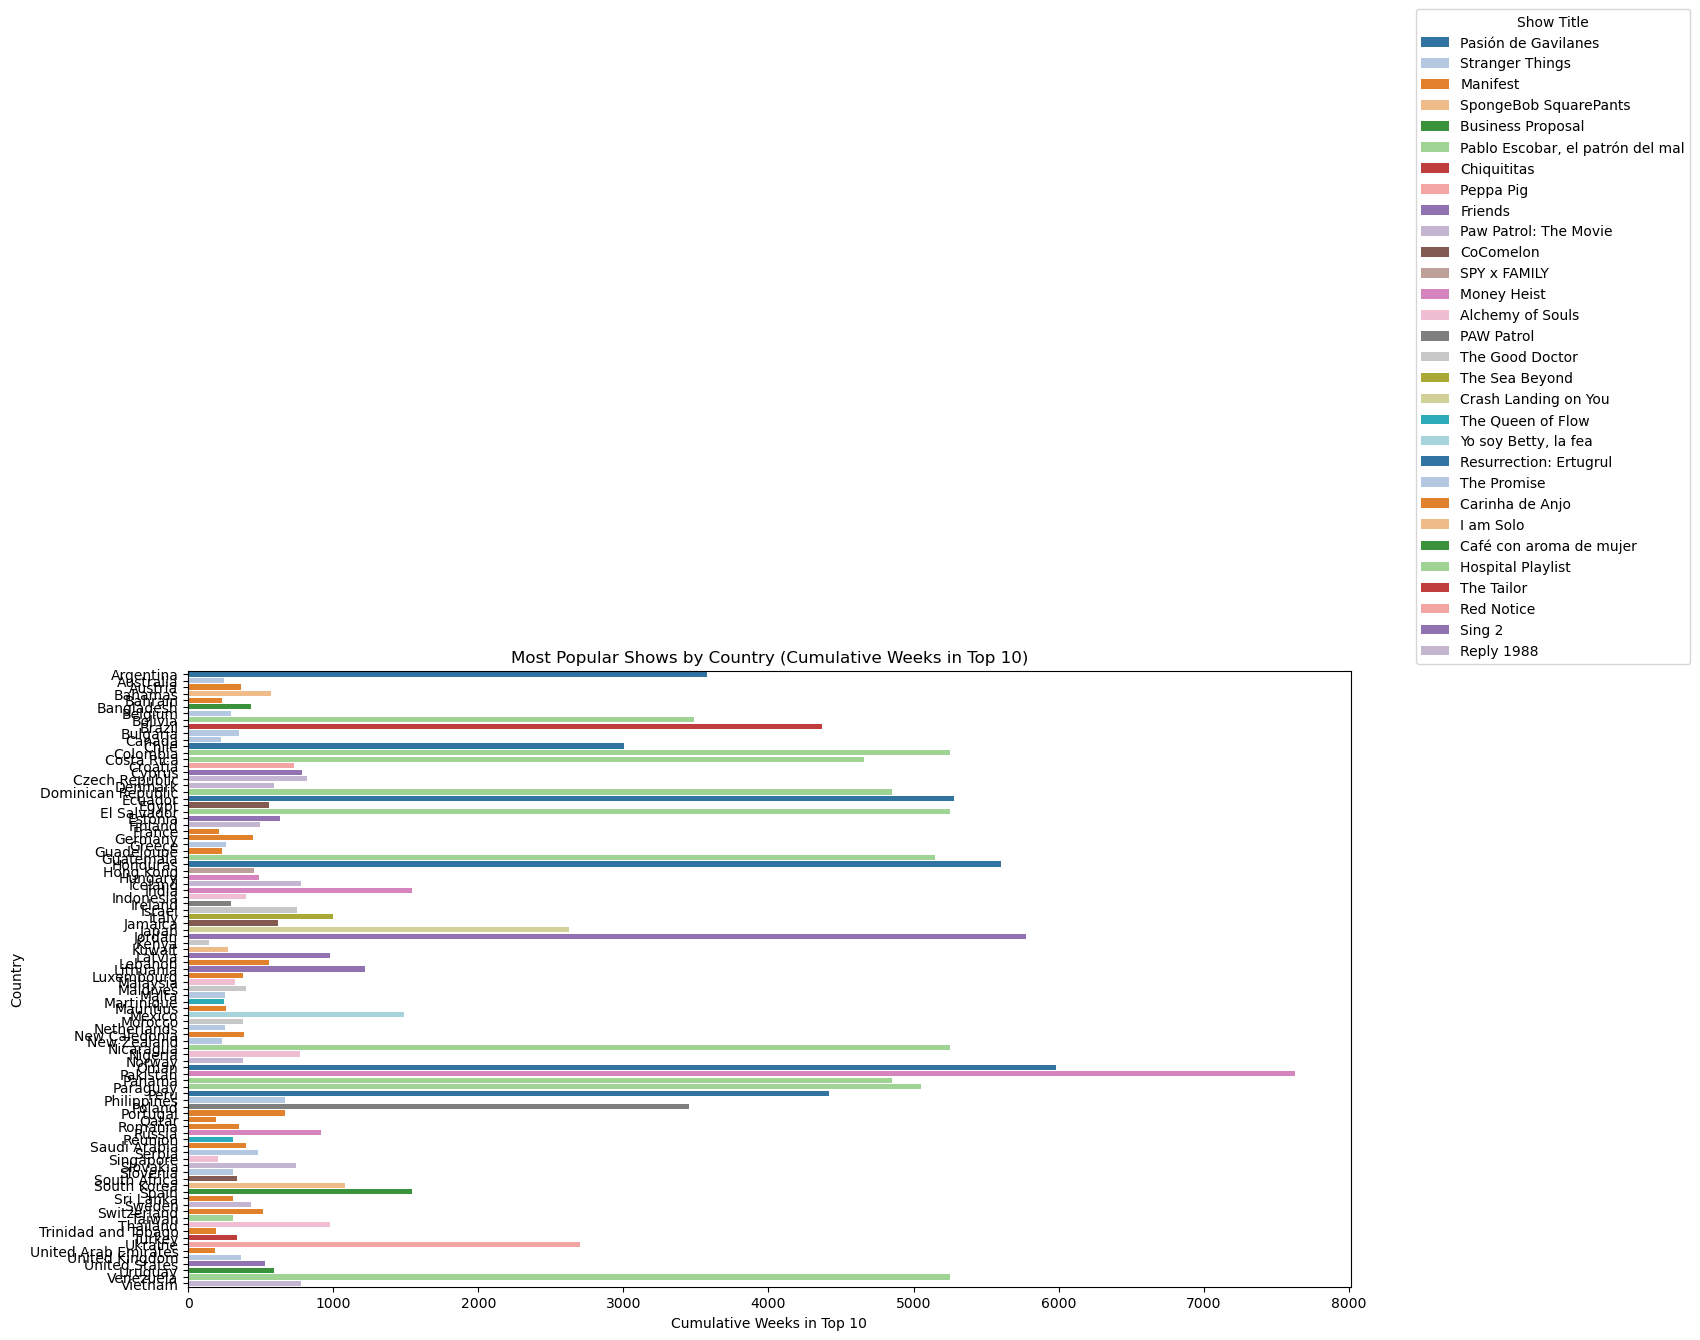

In [11]:
#Regional Trends: Most Popular Shows by Country

# Most popular show by country
popular_shows_country = countries_df.groupby(["country_name", "show_title"])["cumulative_weeks_in_top_10"].sum().reset_index()
top_shows_country = popular_shows_country.loc[popular_shows_country.groupby("country_name")["cumulative_weeks_in_top_10"].idxmax()]

# Visualization: Top show in each country
plt.figure(figsize=(15, 8))
sns.barplot(
    y=top_shows_country["country_name"], 
    x=top_shows_country["cumulative_weeks_in_top_10"], 
    hue=top_shows_country["show_title"], 
    dodge=False, 
    palette="tab20"
)
plt.title("Most Popular Shows by Country (Cumulative Weeks in Top 10)")
plt.xlabel("Cumulative Weeks in Top 10")
plt.ylabel("Country")
plt.legend(bbox_to_anchor=(1.05, 1), title="Show Title")
plt.show()


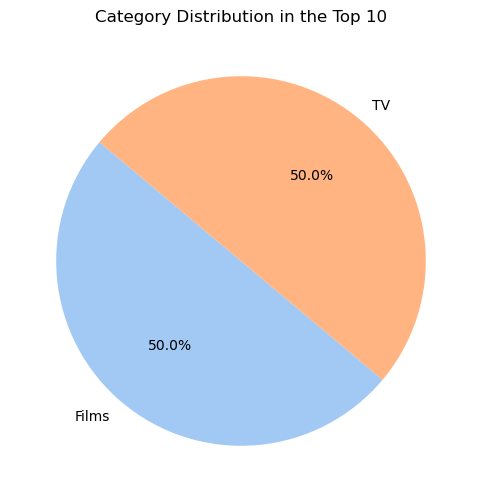

In [12]:
#Understand which categories dominate the Top 10.

# Category distribution
category_distribution = countries_df["category"].value_counts()

# Visualization: Category distribution
plt.figure(figsize=(10, 6))
category_distribution.plot(kind="pie", autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
plt.title("Category Distribution in the Top 10")
plt.ylabel("")  # Hide the y-axis label
plt.show()


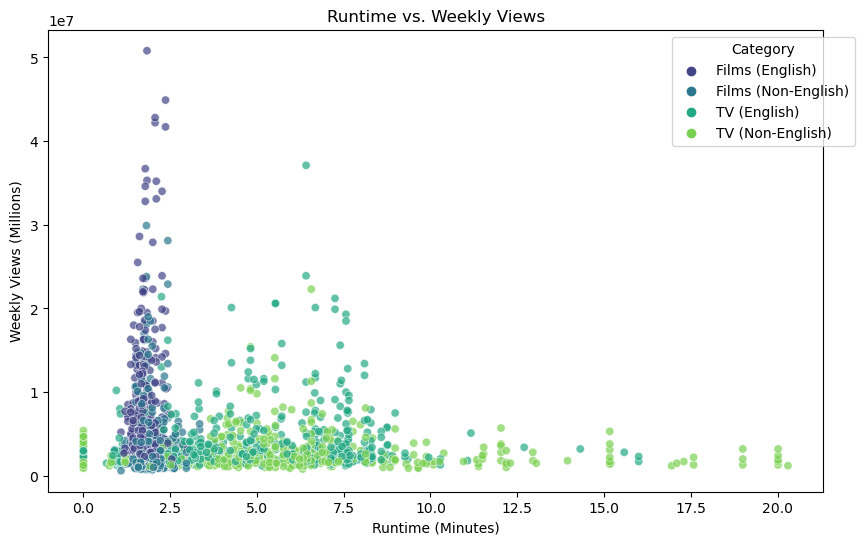

In [13]:
#Visualize the relationship between runtime and weekly_views.

# Scatterplot: Runtime vs. Weekly Views
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=global_df_cleaned["runtime"], 
    y=global_df_cleaned["weekly_views"], 
    hue=global_df_cleaned["category"], 
    palette="viridis", 
    alpha=0.7
)
plt.title("Runtime vs. Weekly Views")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Weekly Views (Millions)")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1))
plt.show()


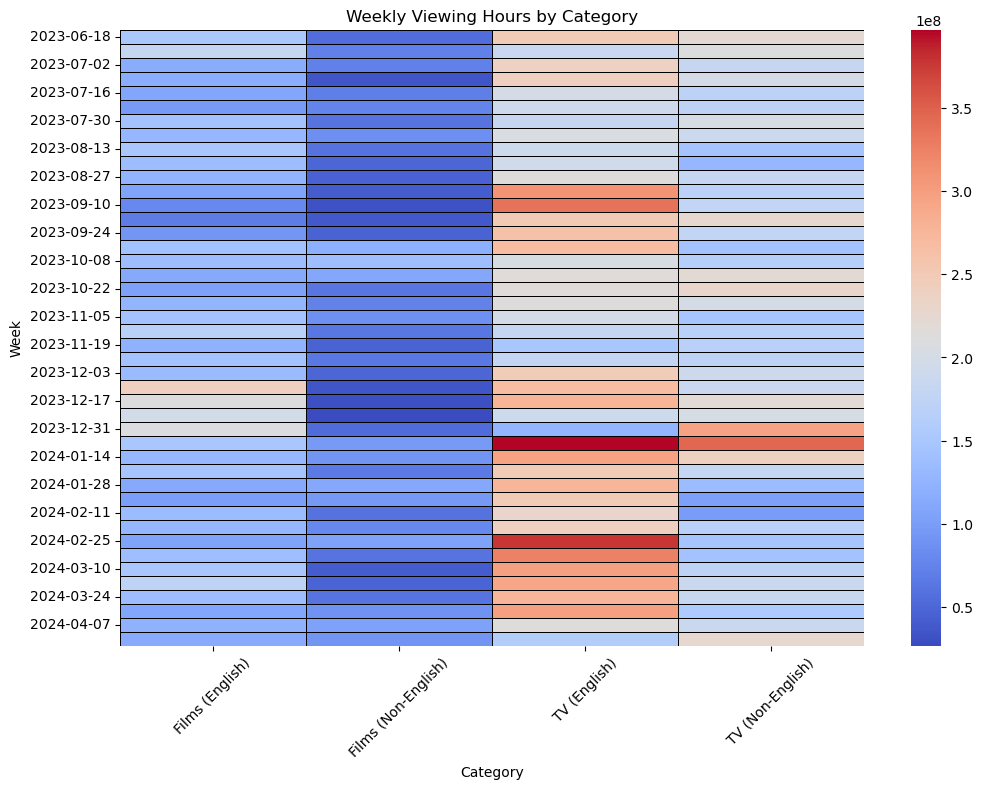

In [14]:
#Highlight viewing trends across categories over time.

# Prepare pivot table for heatmap
heatmap_data = global_df_cleaned.pivot_table(
    index="week", 
    columns="category", 
    values="weekly_hours_viewed", 
    aggfunc="sum"
).fillna(0)

# Visualization: Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="coolwarm", linewidths=0.5, linecolor="black")
plt.title("Weekly Viewing Hours by Category")
plt.xlabel("Category")
plt.ylabel("Week")
plt.xticks(rotation=45)
plt.show()


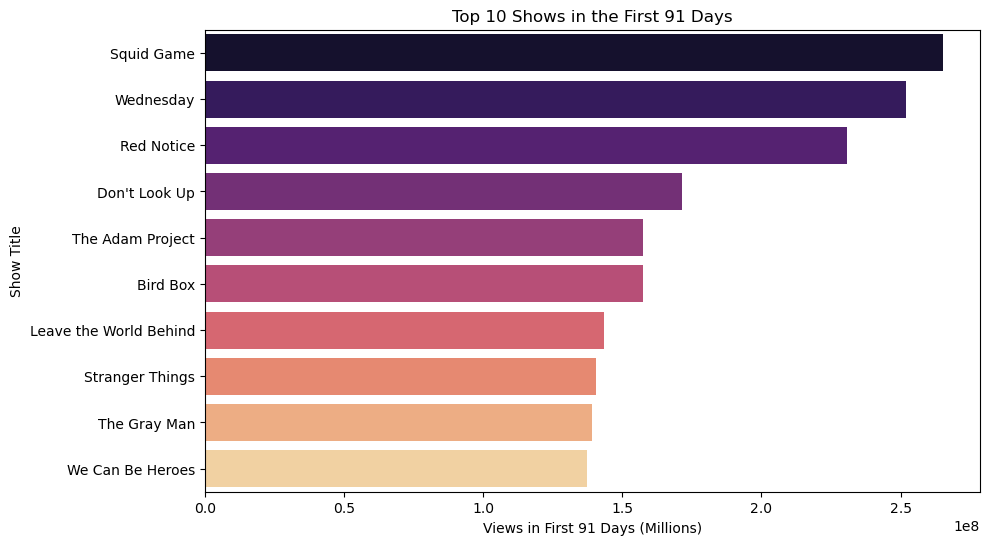

In [15]:
#Top Shows in the First 91 Days

#Compare the most popular shows in their first 91 days based on views.

top_91_days = popular_df.sort_values("views_first_91_days", ascending=False).head(10)

# Visualization: Top shows in the first 91 days
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_91_days["views_first_91_days"], 
    y=top_91_days["show_title"], 
    palette="magma"
)
plt.title("Top 10 Shows in the First 91 Days")
plt.xlabel("Views in First 91 Days (Millions)")
plt.ylabel("Show Title")
plt.show()


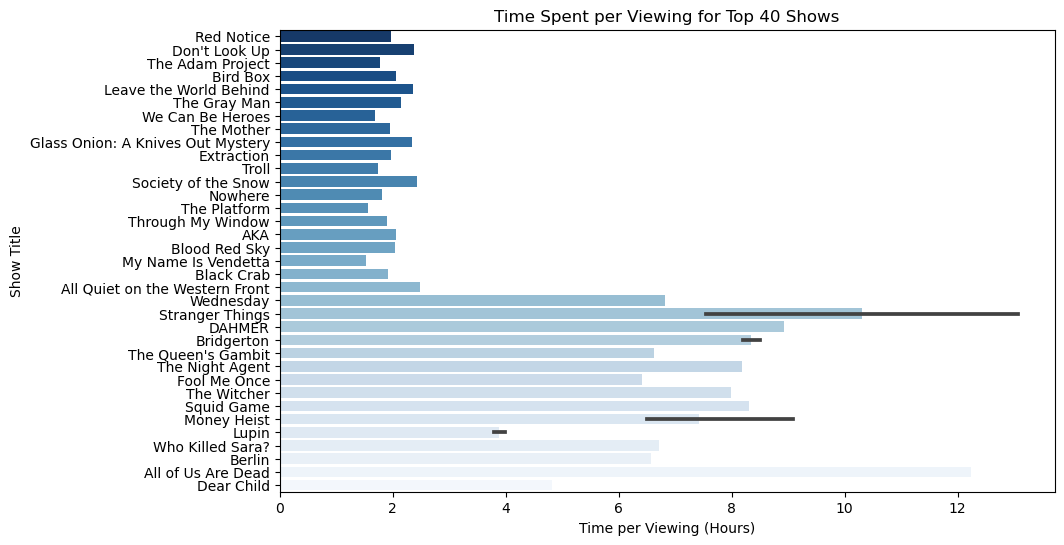

In [16]:
#Analyze how much time users spend watching top shows.

# Calculate time spent per viewing for popular shows
popular_df["time_per_view"] = popular_df["hours_viewed_first_91_days"] / popular_df["views_first_91_days"]

# Visualization: Time spent per viewing
plt.figure(figsize=(10, 6))
sns.barplot(
    x=popular_df["time_per_view"], 
    y=popular_df["show_title"], 
    palette="Blues_r"
)
plt.title("Time Spent per Viewing for Top 40 Shows")
plt.xlabel("Time per Viewing (Hours)")
plt.ylabel("Show Title")
plt.show()



**Let's bring the story to life! Below is how we’ll craft the visuals and narratives for each section, targeting the general public.**

1.Most Popular Titles Globally

Visualization: Bar Chart



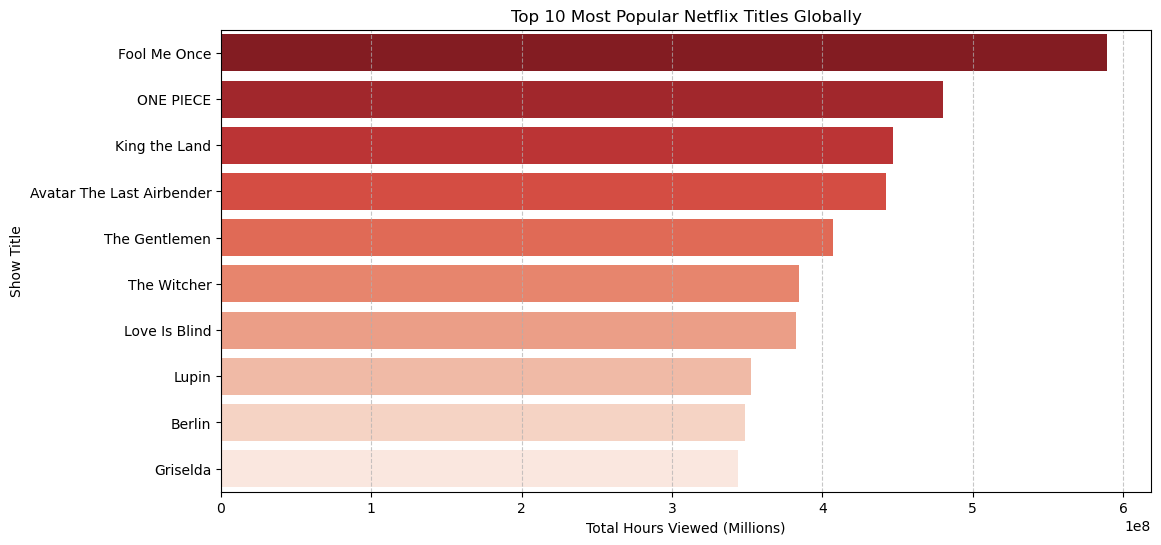

In [18]:
# Top 10 globally popular titles by total hours viewed
global_popularity = global_df_cleaned.groupby("show_title")["weekly_hours_viewed"].sum().sort_values(ascending=False).head(10)

# Bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=global_popularity.values, y=global_popularity.index, palette="Reds_r")
plt.title("Top 10 Most Popular Netflix Titles Globally")
plt.xlabel("Total Hours Viewed (Millions)")
plt.ylabel("Show Title")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


2.Trending Categories Over Time

Visualization: Line Graph

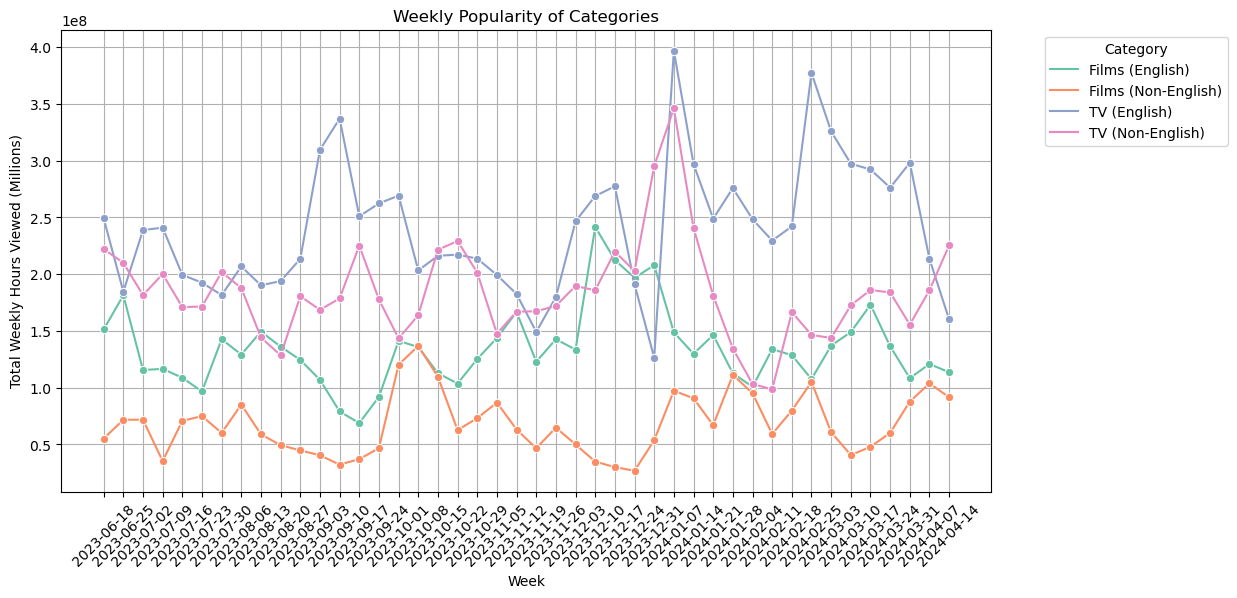

In [20]:
# Weekly category trends
category_trends = global_df_cleaned.groupby(["week", "category"])["weekly_hours_viewed"].sum().reset_index()

# Line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=category_trends, x="week", y="weekly_hours_viewed", hue="category", marker="o", palette="Set2")
plt.title("Weekly Popularity of Categories")
plt.xlabel("Week")
plt.ylabel("Total Weekly Hours Viewed (Millions)")
plt.xticks(rotation=45)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid()
plt.show()


 3.Rise of New Hits
    
Visualization: Timeline

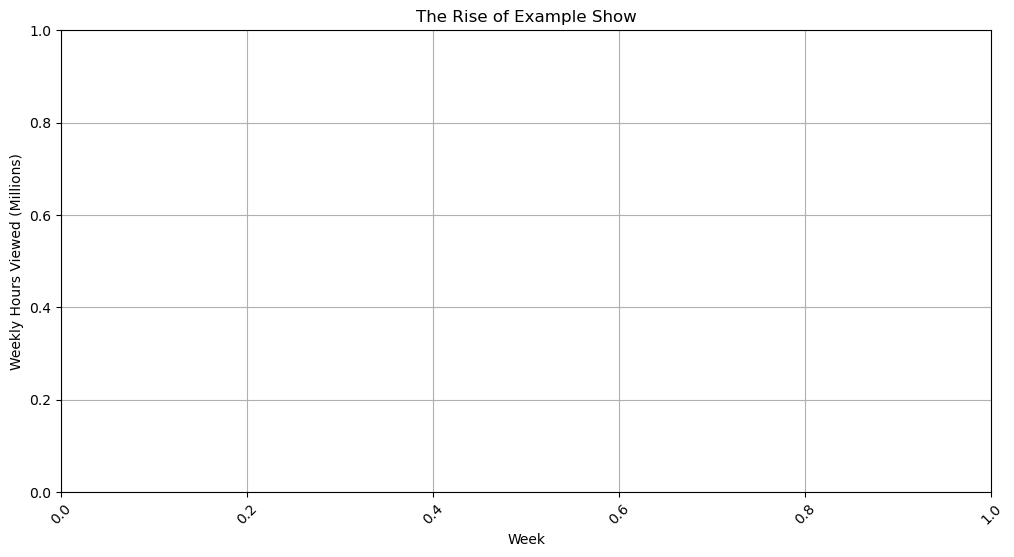

In [26]:
# Breakout title example: Focus on a single show
breakout_title = "Example Show"
breakout_data = global_df_cleaned[global_df_cleaned["show_title"] == breakout_title]

# Line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=breakout_data, x="week", y="weekly_hours_viewed", marker="o", color="red")
plt.title(f"The Rise of {breakout_title}")
plt.xlabel("Week")
plt.ylabel("Weekly Hours Viewed (Millions)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


4.Battle of Categories

Visualization: Pie Chart

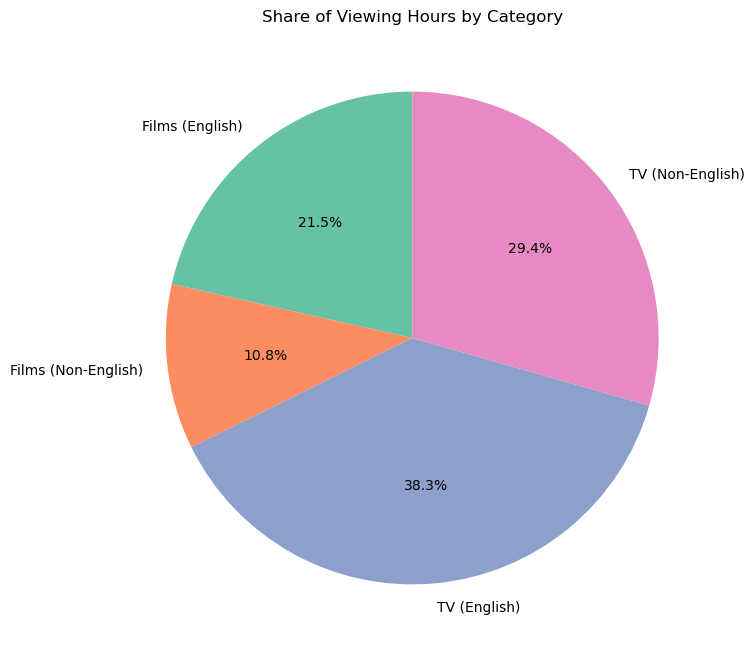

In [27]:
# Viewing share by category
category_share = global_df_cleaned.groupby("category")["weekly_hours_viewed"].sum()

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    category_share.values, 
    labels=category_share.index, 
    autopct="%1.1f%%", 
    startangle=90, 
    colors=sns.color_palette("Set2")
)
plt.title("Share of Viewing Hours by Category")
plt.show()


5.Cumulative Viewing Hours

Visualization: Single Number Highlight

In [29]:
# Total viewing hours
total_hours = global_df_cleaned["weekly_hours_viewed"].sum()

# Display
print(f"Total Viewing Hours: {total_hours:.0f} Million")


Total Viewing Hours: 27625500000 Million
